# Tutorial 3 - ARMA

Empirical exercise. Using the data in `AuQuGDP.csv`, we will analyze the Australia quarterly GDP from 1960Q1 to 2020Q1, which is measured in 2007 Australian dollars and seasonally adjusted.

**Note: the `AuGDP` series has come through with some rounded data that makes for the piece-wise looking time series. The methods are still correct, the underlying data is not. I don't have the original dataset to fix this so this will have to do.**

### Load packages

In [1]:
%reset -f

import pandas            as pd
import matplotlib.pyplot as plt
import statsmodels.api   as sm
import seaborn           as sns
import numpy             as np

from datetime                    import datetime
from statsmodels.tsa.stattools   import adfuller
from statsmodels.tsa.arima.model import ARIMA

### Set up seaborn parameters for plotting

In [2]:
pd.plotting.register_matplotlib_converters()
# Default figure size
sns.mpl.rc('figure',figsize=(16, 6))
pd.set_option('display.float_format', lambda x: '%.2f' % x) # makes numbers nice

### Load Data

In [3]:
df = pd.read_csv("AuQuGDP.csv")

In [4]:
df.head()

,Unnamed: 0,Time,AuGDP,quarter,year,t
0,0,1/01/1960,64683000000.00,1,1960,1/01/1960
1,1,1/04/1960,66473000000.00,2,1960,1/04/1960
2,2,1/07/1960,66623000000.00,3,1960,1/07/1960
3,3,1/10/1960,66490000000.00,4,1960,1/10/1960
4,4,1/01/1961,66690000000.00,1,1961,1/01/1961


### Set time index

In [5]:
df['date'] = pd.to_datetime(df['Time'])
df = df.set_index('date')
df.drop(['Time'], axis = 1, inplace = True)
df.head()

,Unnamed: 0,AuGDP,quarter,year,t
date,,,,,
1960-01-01,0,64683000000.00,1,1960,1/01/1960
1960-01-04,1,66473000000.00,2,1960,1/04/1960
1960-01-07,2,66623000000.00,3,1960,1/07/1960
1960-01-10,3,66490000000.00,4,1960,1/10/1960
1961-01-01,4,66690000000.00,1,1961,1/01/1961


### (a). graph of GDP & ADF Test
**Draw a time series graph of GDP. Does the series look stationary? To confirm your guess, run the augmented DF test of unit root**.

Fails the ADF test - is a non-stationary series. 

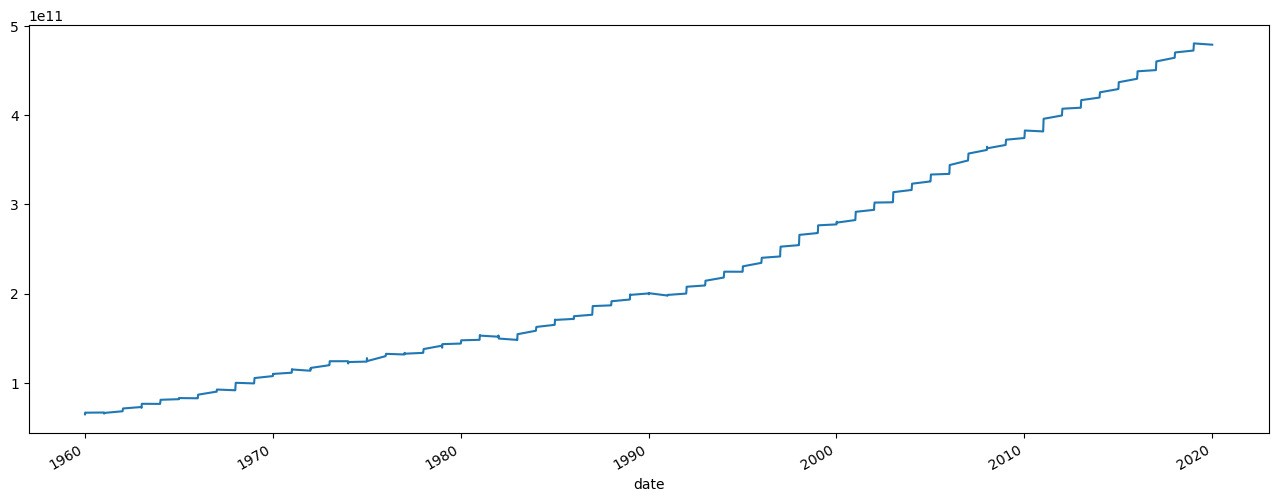

In [6]:
df['AuGDP'].plot()
plt.show()

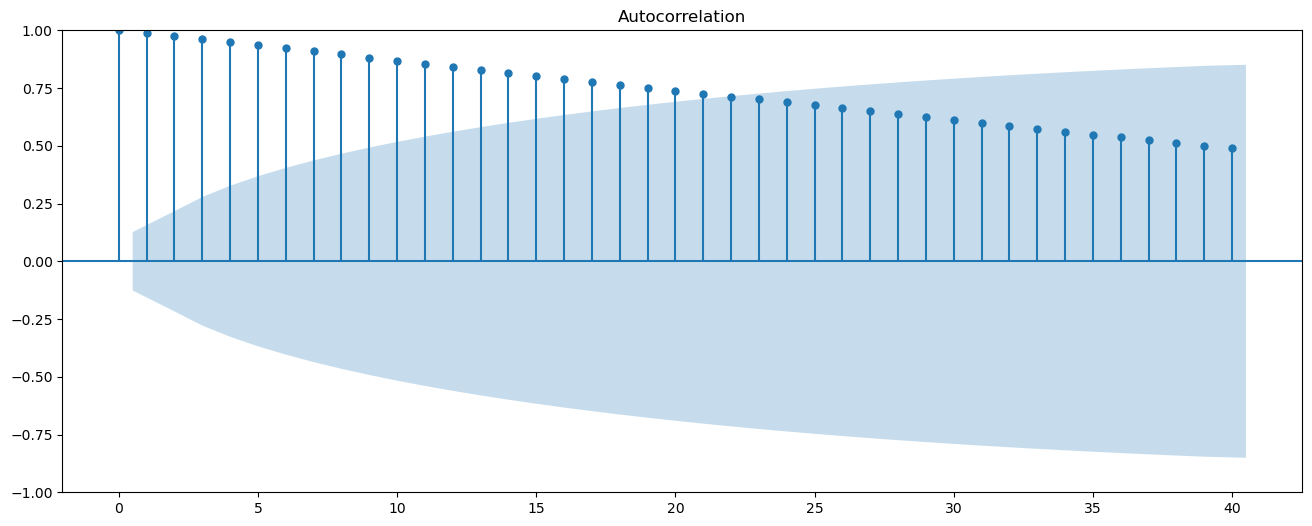

In [7]:
### we can verify the stationarity of the series we can plot the ACF figure
sm.graphics.tsa.plot_acf(df['AuGDP'].values.squeeze(),lags=40)
plt.show()

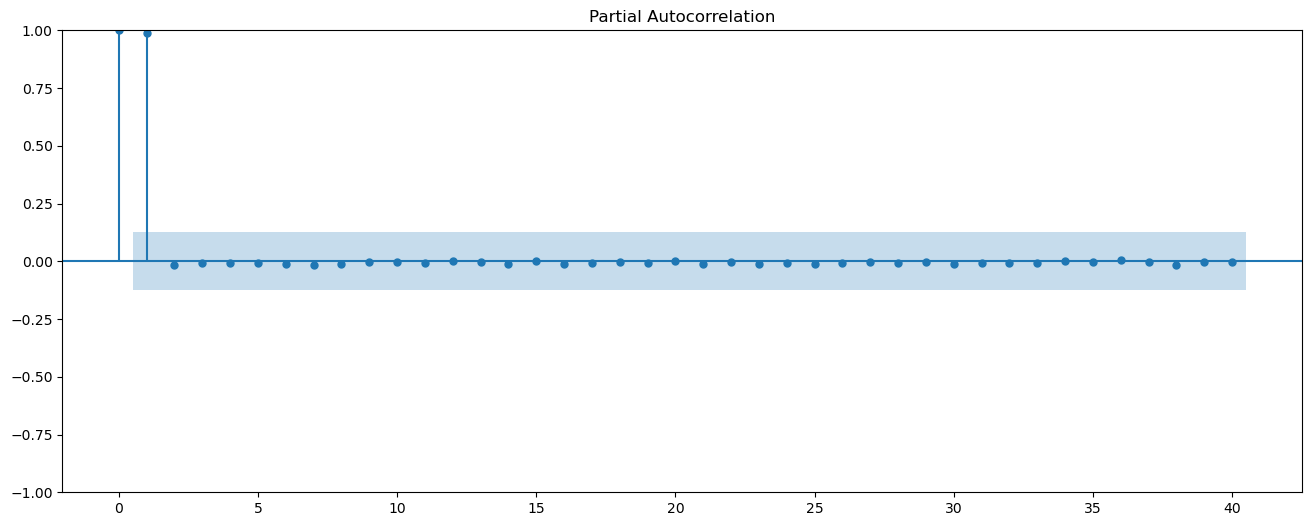

In [8]:
sm.graphics.tsa.plot_pacf(df['AuGDP'].values.squeeze(),lags=40)
plt.show()

In [9]:
### we can run the Augmented Dickey-Fuller test (ADF)
X = df['AuGDP'].values
result1=adfuller(X,regression='ct',maxlag=3,regresults=True,store=True)
#result=adfuller(X,regression='ct',autolag='BIC',regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result1[0], result1[1], result1[2]))

 ADF statistic: -0.346, 
 p-value: 0.988, 
 critical value: {'1%': -3.9969944961660877, '5%': -3.4289434905960645, '10%': -3.1378930946180557}


### (b). First Difference Graph and ADF
Similar to the empirical example in the lecture, the GDP series can be transformed into a stationary one by taking first difference, which is also the quarterly GDP growth. Generate the quarterly GDP growth $\Delta GDP$ and run the
augmented DF unit root test on {$\Delta GDP$}.

In [10]:
df2 = df
df2['GDP_D1'] = df2['AuGDP'].diff()
df2 = df2.dropna(axis = 0)

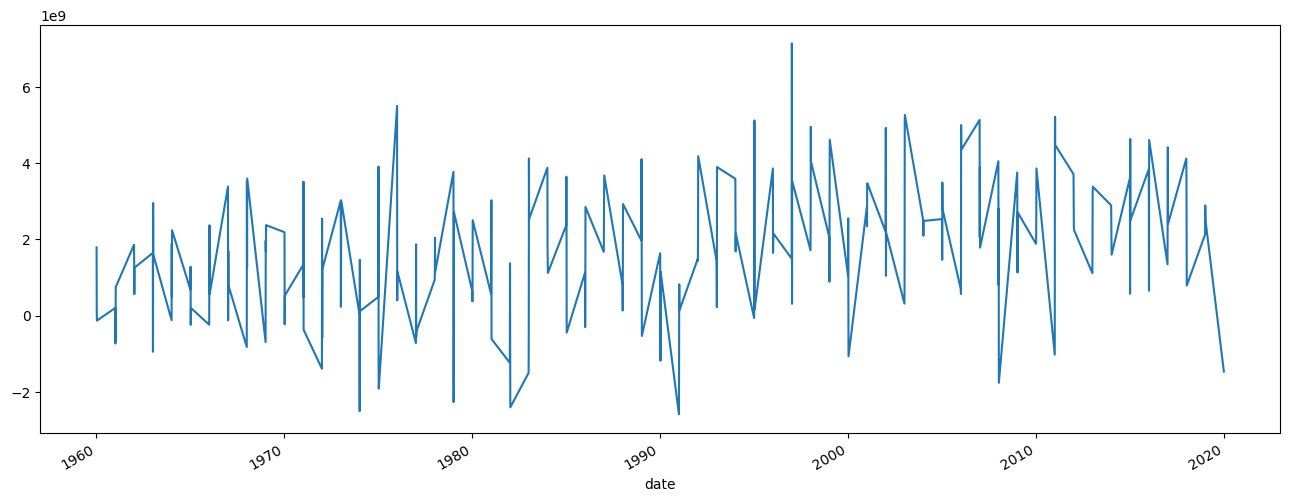

In [11]:
df2['GDP_D1'].plot()
plt.show()

In [12]:
### ADF
X2 = df2['GDP_D1'].values
result2=adfuller(X2,regression='ct',maxlag=3,regresults=True,store=True)
#result=adfuller(X,regression='ct',autolag='BIC',regresults=True,store=True)
print(out.format(result2[0], result2[1], result2[2]))

 ADF statistic: -15.258, 
 p-value: 0.000, 
 critical value: {'1%': -3.99715658668426, '5%': -3.4290213886201637, '10%': -3.137938763154836}


### (c). ACF and PACF plots for GDP_D1
**Find and plot the ACF and PACF of 4GDP , which may provide hints on the order determination of AR and MA models.**

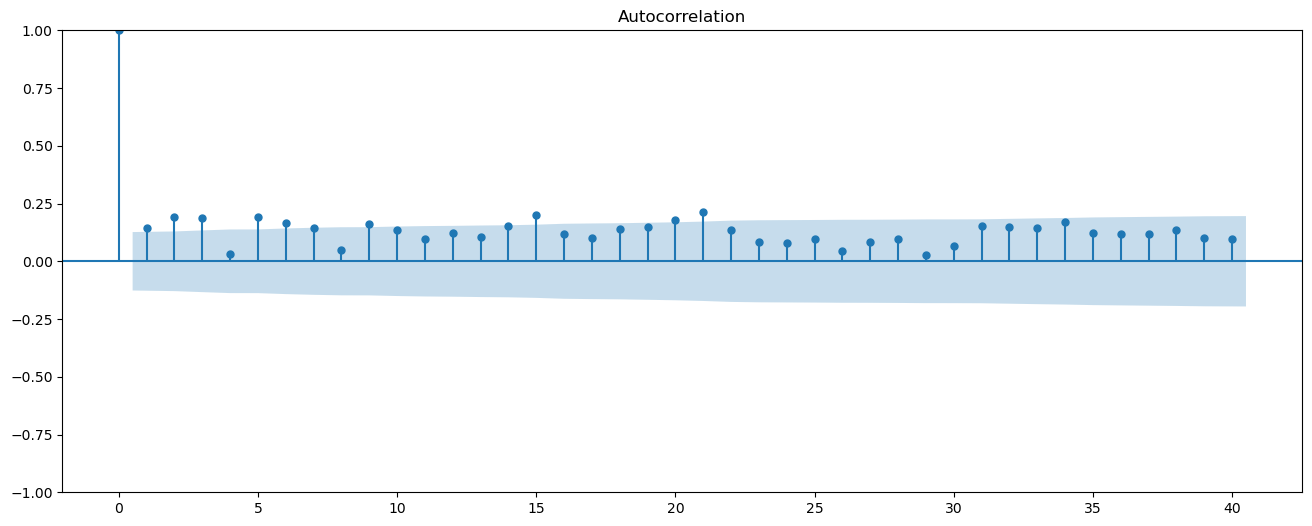

In [13]:
sm.graphics.tsa.plot_acf(df2['GDP_D1'].values.squeeze(), lags=40)
plt.show()

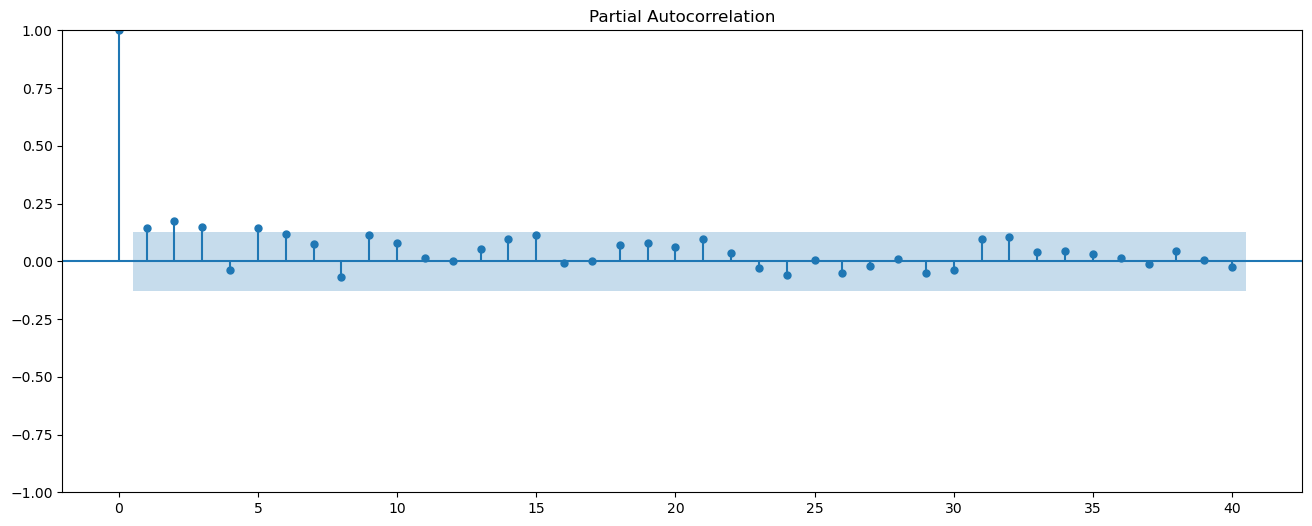

In [14]:
sm.graphics.tsa.plot_pacf(df2['GDP_D1'].values.squeeze(), lags=40)
plt.show()

### (d). Modeling and predicting AR(p)
**Based on the PACF, propose an AR model for $\Delta GDP$ , estimate the model using observations up to 2018Q4, and report the results. Express the AR model with the estimated coefficients.**

PACF suggests $AR(5)$ is appropriate:

In [15]:
mod_AR = ARIMA(df2['GDP_D1'][df2.index.year<=2018], order=(5,0,0))
res_AR = mod_AR.fit()
print(res_AR.summary())

                               SARIMAX Results                                
Dep. Variable:                 GDP_D1   No. Observations:                  235
Model:                 ARIMA(5, 0, 0)   Log Likelihood               -5319.911
Date:                Thu, 20 Aug 2026   AIC                          10653.822
Time:                        22:01:06   BIC                          10678.040
Sample:                             0   HQIC                         10663.586
                                - 235                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.725e+09   6.08e-12   2.84e+20      0.000    1.73e+09    1.73e+09
ar.L1          0.1059      0.060      1.767      0.077      -0.012       0.223
ar.L2          0.1458      0.066      2.194      0.0

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


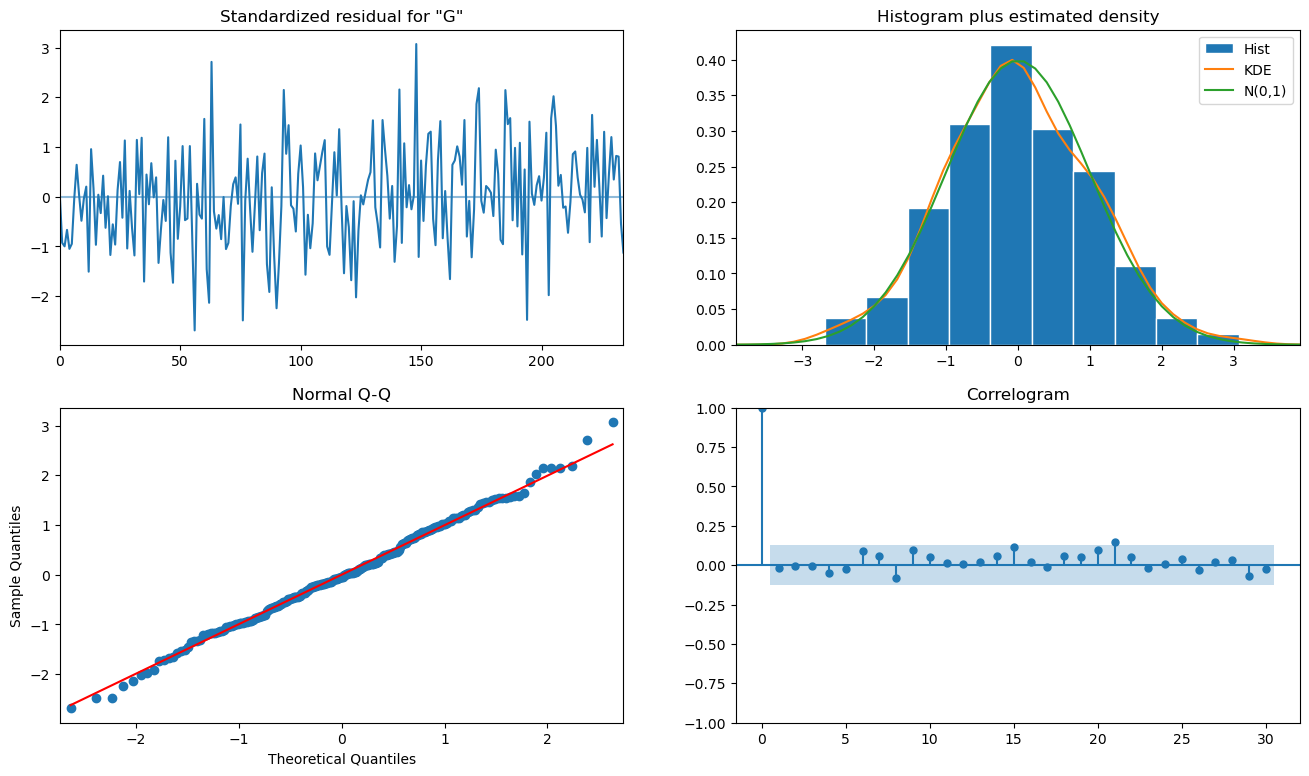

In [16]:
fig = plt.figure(figsize =(16,9))
fig = res_AR.plot_diagnostics(fig=fig, lags = 30)

### (e). j-period ahead forecasts AR(p)

**Based on the AR model in (d), perform the 1-quarter ahead and 1-year (4-quarter) ahead forecasting with 2018Q4 as the forecast origin, and respectively calculate the forecast residuals (forecast error + estimation error).**

In [17]:
res_AR.forecast(steps=1)

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


235   1811563945.41
dtype: float64

In [18]:
res_AR.forecast(steps=1) - df2['GDP_D1'][df2.index=="2019-01-01"].values

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


235   -315436054.59
dtype: float64

In [19]:
res_AR.forecast(steps = 4) 

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


235   1811563945.41
236   1782158628.80
237   1891436803.27
238   1782371800.92
Name: predicted_mean, dtype: float64

In [20]:
res_AR.forecast(steps = 4) - df2['GDP_D1'][df2.index.year == 2019].values

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


235    -315436054.59
236   -1106841371.20
237    -743563196.73
238    -706628199.08
Name: predicted_mean, dtype: float64

### (f). MA(q) modeling.

In [21]:
mod_MA = ARIMA(df2['GDP_D1'][df2.index.year<=2018], order=(0,0,6))
res_MA = mod_MA.fit()
print(res_MA.summary())

                               SARIMAX Results                                
Dep. Variable:                 GDP_D1   No. Observations:                  235
Model:                 ARIMA(0, 0, 6)   Log Likelihood               -5319.038
Date:                Thu, 20 Aug 2026   AIC                          10654.076
Time:                        22:01:07   BIC                          10681.753
Sample:                             0   HQIC                         10665.234
                                - 235                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.725e+09   6.68e-12   2.58e+20      0.000    1.73e+09    1.73e+09
ma.L1          0.0879      0.067      1.308      0.191      -0.044       0.220
ma.L2          0.1718      0.072      2.390      0.0

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


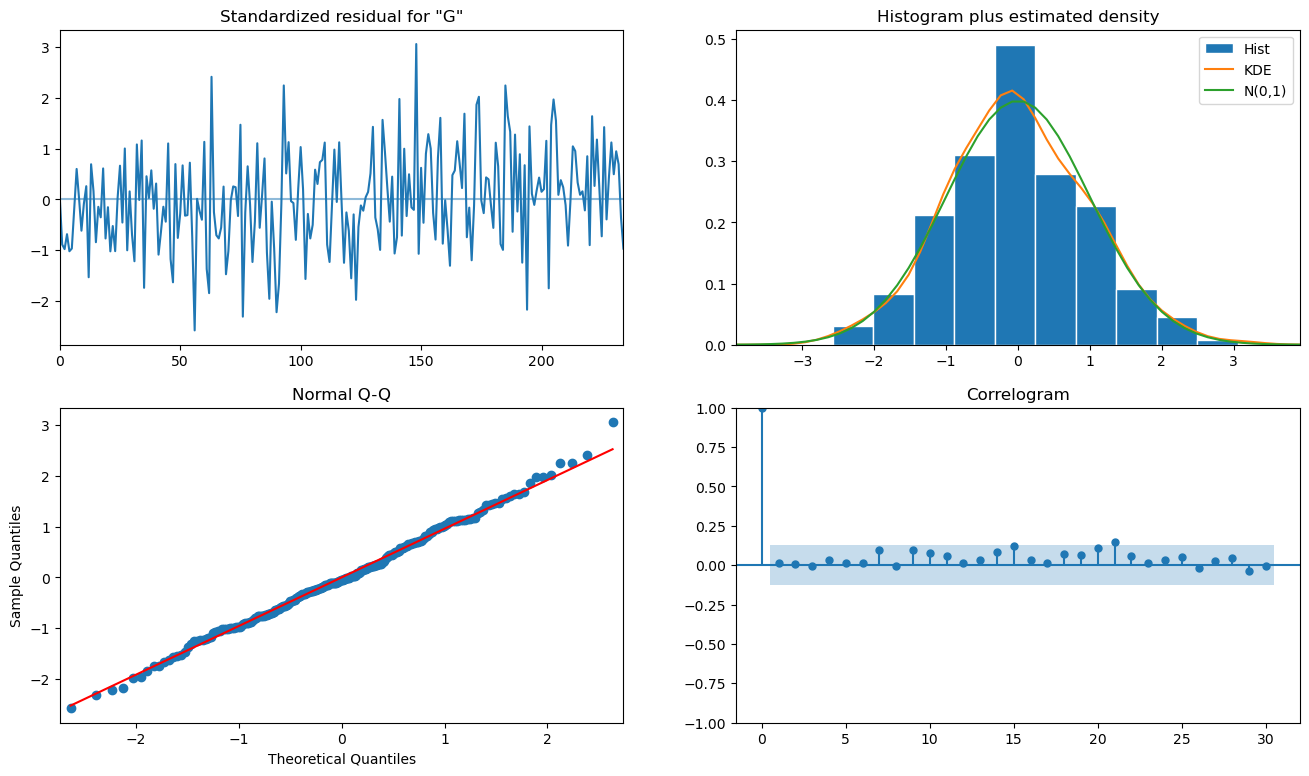

In [22]:
fig = plt.figure(figsize =(16,9))
fig = res_MA.plot_diagnostics(fig=fig, lags = 30)

### (g). j-period ahead forecasts MA(q)

**Based on the ACF, propose an MA model for 4GDP , estimate the model using observations up to 2018Q4, and report the results. Express the MA model with the estimated coefficients.**


In [23]:
res_MA.forecast(steps = 1)

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


235   1884414537.44
dtype: float64

In [24]:
res_MA.forecast(steps = 1) - res_AR.forecast(steps=1) - df2['GDP_D1'][df2.index=="2019-01-01"].values

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


235   -2054149407.97
dtype: float64

In [25]:
res_MA.forecast(steps = 4)

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


235   1884414537.44
236   1559539668.48
237   1864561957.42
238   1937100042.77
Name: predicted_mean, dtype: float64

In [26]:
res_MA.forecast(steps = 4)  - df2['GDP_D1'][df2.index.year == 2019].values

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


235    -242585462.56
236   -1329460331.52
237    -770438042.58
238    -551899957.23
Name: predicted_mean, dtype: float64

In [27]:
df2['GDP_D1'][df2.index.year == 2019]

date
2019-01-01   2127000000.00
2019-01-04   2889000000.00
2019-01-07   2635000000.00
2019-01-10   2489000000.00
Name: GDP_D1, dtype: float64